# TelcoX Customer Segmentation: Segmentation Analysis

| | |
|---|---|
| **Project** | TelcoX Customer Segmentation (fictional company, synthetic data) |
| **Notebook** | Segmentation analysis |
| **Prepared by** | Walusungu |
| **Related documents** | 03 Requirements and User Stories, 04 Data Dictionary |

## What this notebook does

TelcoX wants to group its customers by how they actually use its services, so that marketing can send each group a suitable offer. This notebook finds those groups using K-means clustering. K-means sorts customers into groups so that people in the same group behave alike, and people in different groups behave differently.

The notebook is built in four stages. Each stage starts with a plain explanation of what we are doing and why.

| Stage | What happens | Requirements covered |
|---|---|---|
| **1. Data preparation** (this stage) | Check the data, fix problems, create new measures, and put everything on the same scale. | FR2 to FR5 |
| 2. Choose the number of segments | Test different numbers of groups and pick the best one. | FR6, FR8 |
| 3. Build the segments | Run K-means, place every customer in a segment, and test stability again on subsamples. | FR7 |
| 4. Profile the segments | Describe each group and rank them by upgrade potential. | FR9 to FR11 |

**How to run:** first create the data with `python src/generate_telcox_data.py`, then run this notebook from the `notebooks` folder. The random seed is fixed, so the results are the same each time (requirement NFR2).

---
# Stage 1: Data preparation

Good segments depend on clean data. In this stage we go through six short steps:

1. Set up the tools
2. Load the data
3. Check the data quality
4. Fix the problems
5. Create new measures
6. Choose and scale the features used for grouping

## Step 1.1 Set up the tools

We load the Python tools we need and set a fixed random seed. A fixed seed means any random step gives the same result every time the notebook runs.

We also write down the plan table from the data dictionary (section 3). We will use it later to check that each customer's plan allowances are correct.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

DATA_PATH = "../data/telcox_customers.csv"
CLEAN_PATH = "../data/telcox_clean.csv"

# The four TelcoX plans (data dictionary, section 3)
PLAN_TABLE = pd.DataFrame(
    {
        "plan_price": [10, 20, 35, 55],
        "plan_data_gb": [5, 15, 40, 100],
        "plan_voice_min": [100, 300, 600, 1000],
    },
    index=["Basic", "Standard", "Plus", "Premium"],
)
PLAN_TABLE

,plan_price,plan_data_gb,plan_voice_min
Basic,10,5,100
Standard,20,15,300
Plus,35,40,600
Premium,55,100,1000


## Step 1.2 Load the data

We read the customer table and look at its size and the first few rows. Each row should be one customer.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 15,060   Columns: 29


,customer_id,age_group,gender,area_type,region,registration_channel,account_type,tenure_months,current_plan,plan_price,plan_data_gb,plan_voice_min,has_home_broadband,avg_data_gb,avg_voice_min,avg_sms,offpeak_share,roaming_days_3m,broadband_gb,months_over_data_limit,avg_monthly_spend,topups_per_month,avg_topup_amount,bundle_purchases_3m,late_payments_6m,upgrades_24m,months_since_last_upgrade,promos_received_6m,promos_accepted_6m
0,TX011558,NaN,Female,Rural,South,Self-service,Prepaid,24,Standard,20,15,300,No,13.26,148.0,212,0.37,0,NaN,1,23.60,5.6,3.78,1,NaN,0,NaN,11,1
1,TX008019,35-44,Female,Rural,East,Retail shop,Postpaid,20,Premium,55,100,1000,Yes,4.98,377.2,32,0.18,0,122.8,0,54.39,NaN,NaN,0,1.0,0,NaN,6,0
2,TX008162,25-34,Male,Urban,West,Retail shop,Prepaid,26,Basic,10,5,100,No,23.35,224.9,92,0.55,0,NaN,3,17.35,5.9,2.80,2,NaN,1,9.0,3,1
3,TX013834,45-54,Female,Urban,Central,Retail shop,Postpaid,32,Premium,55,100,1000,No,15.41,947.4,69,0.27,6,NaN,0,51.38,NaN,NaN,0,0.0,0,NaN,4,0
4,TX008954,55+,Female,Urban,West,Reseller,Prepaid,26,Plus,35,40,600,No,13.47,195.5,74,0.29,0,NaN,0,34.14,2.6,12.93,2,NaN,0,NaN,3,1


## Step 1.3 Check the data quality

Before changing anything, we look for four kinds of problems (requirement FR2):

- **Missing values.** Some are expected. For example, a postpaid customer has no top-ups, so that field is empty by design. Others are real gaps.
- **Duplicate customers.** The same customer appearing twice would count double.
- **Inconsistent plan records.** A plan's allowance should match its name.
- **Extreme values.** Very large numbers can pull the groups towards a few unusual customers.

In [3]:
reasons = {
    "topups_per_month": "By design: postpaid customers do not top up",
    "avg_topup_amount": "By design: postpaid customers do not top up",
    "late_payments_6m": "By design: prepaid customers have no bills",
    "broadband_gb": "By design: customer has no home broadband",
    "months_since_last_upgrade": "By design: customer has never upgraded",
    "age_group": "Real gap: age was not recorded",
}

missing = raw.isna().sum()
missing = missing[missing > 0]
missing_table = pd.DataFrame(
    {
        "empty_cells": missing,
        "percent_of_customers": (missing / len(raw) * 100).round(1),
        "reason": [reasons.get(col, "Check this field") for col in missing.index],
    }
).sort_values("percent_of_customers", ascending=False)
missing_table

,empty_cells,percent_of_customers,reason
months_since_last_upgrade,12406,82.4,By design: customer has never upgraded
broadband_gb,11751,78.0,By design: customer has no home broadband
late_payments_6m,7887,52.4,By design: prepaid customers have no bills
avg_topup_amount,7173,47.6,By design: postpaid customers do not top up
topups_per_month,7173,47.6,By design: postpaid customers do not top up
age_group,1655,11.0,Real gap: age was not recorded


In [4]:
duplicate_customers = raw.duplicated(subset="customer_id").sum()
print(f"Repeated customer records: {duplicate_customers}")

def count_wrong_plan_records(frame):
    wrong = pd.Series(False, index=frame.index)
    for col in PLAN_TABLE.columns:
        wrong |= frame[col] != frame["current_plan"].map(PLAN_TABLE[col])
    return int(wrong.sum())

print(f"Records where the plan allowance does not match the plan name: "
      f"{count_wrong_plan_records(raw)}")

Repeated customer records: 60
Records where the plan allowance does not match the plan name: 33


In [5]:
check_cols = ["avg_data_gb", "avg_voice_min", "avg_sms", "broadband_gb"]
extremes = raw[check_cols].describe(percentiles=[0.5, 0.99]).loc[["50%", "99%", "max"]].T.round(1)
extremes["max_vs_median"] = (extremes["max"] / extremes["50%"]).round(1)
extremes

,50%,99%,max,max_vs_median
avg_data_gb,6.9,54.3,119.4,17.3
avg_voice_min,167.7,1190.7,1500.0,8.9
avg_sms,64.0,298.4,500.0,7.8
broadband_gb,107.2,336.9,777.3,7.3


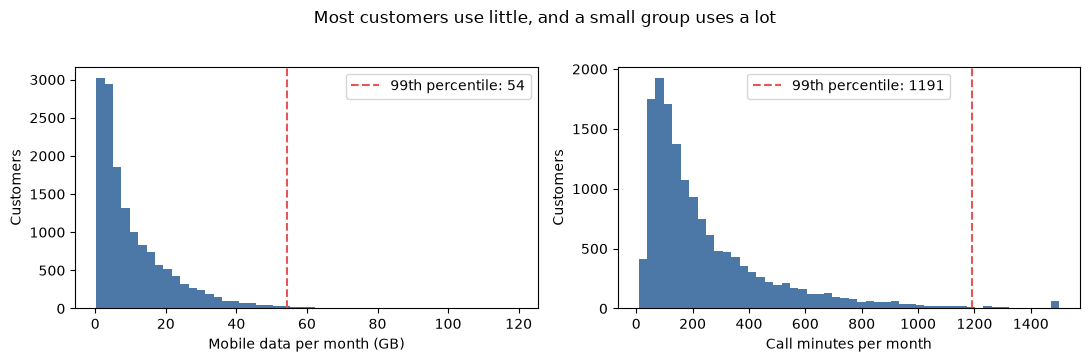

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, label in zip(axes, ["avg_data_gb", "avg_voice_min"],
                          ["Mobile data per month (GB)", "Call minutes per month"]):
    ax.hist(raw[col], bins=50, color="#4C78A8")
    p99 = raw[col].quantile(0.99)
    ax.axvline(p99, color="#E45756", linestyle="--", label=f"99th percentile: {p99:.0f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Customers")
    ax.legend()
plt.suptitle("Most customers use little, and a small group uses a lot", y=1.02)
plt.tight_layout()
plt.show()

**What we found**

- Several fields are empty, but most are empty for a good reason. Only `age_group` is a real gap, and it is mostly missing for prepaid customers.
- A small number of customers appear twice.
- A few plan records have an allowance that does not match the plan name.
- Usage is heavily skewed. A small group of customers uses many times more than the typical customer.

## Step 1.4 Fix the problems

Now we fix what we found (requirement FR3). Each fix is recorded in a log, so anyone can see what was changed and why.

| Problem | How we handle it | Reason |
|---|---|---|
| Repeated customers | Keep the first record, remove the rest | Each customer should count once. |
| Wrong plan allowance | Replace it with the allowance from the plan table | The plan name is the more reliable field. |
| Missing age | Label as "Not stated" | Removing these customers would lose a large part of the prepaid base. |
| No broadband | Set broadband data to 0 | These customers use no home broadband data. |
| No top-ups (postpaid) | Set top-up fields to 0 | Postpaid customers do not top up. |
| Late payments and months since last upgrade | Leave empty | These are used to describe segments later, not to create them. |

Extreme values are handled later, in Step 1.6. We keep the real values in this table so that the segment profiles show true usage.

In [7]:
df = raw.copy()
fix_log = []

def log(problem, affected, handling):
    fix_log.append({"Problem": problem, "Affected": affected, "Handling": handling})

before = len(df)
df = df.drop_duplicates(subset="customer_id", keep="first").reset_index(drop=True)
log("Repeated customer records", before - len(df), "Removed")

wrong_plan = count_wrong_plan_records(df)
for col in PLAN_TABLE.columns:
    df[col] = df["current_plan"].map(PLAN_TABLE[col])
log("Plan allowance does not match plan name", wrong_plan, "Corrected from plan table")

missing_age = int(df["age_group"].isna().sum())
df["age_group"] = df["age_group"].fillna("Not stated")
log("Age not recorded", missing_age, 'Labelled "Not stated"')

no_broadband = int(df["broadband_gb"].isna().sum())
df["broadband_gb"] = df["broadband_gb"].fillna(0)
log("No home broadband (empty broadband use)", no_broadband, "Set to 0")


postpaid = int(df["topups_per_month"].isna().sum())
df[["topups_per_month", "avg_topup_amount"]] = df[["topups_per_month", "avg_topup_amount"]].fillna(0)
log("Postpaid customers with no top-ups", postpaid, "Set to 0")

fix_log = pd.DataFrame(fix_log)
print(f"Customers after cleaning: {len(df):,}")
fix_log

Customers after cleaning: 15,000


,Problem,Affected,Handling
0,Repeated customer records,60,Removed
1,Plan allowance does not match plan name,33,Corrected from plan table
2,Age not recorded,1649,"Labelled ""Not stated"""
3,No home broadband (empty broadband use),11711,Set to 0
4,Postpaid customers with no top-ups,7146,Set to 0


## Step 1.5 Create new measures

Some of the most useful information is not in the raw fields. We create five measures (requirement FR4, data dictionary section 5):

| Measure | What it tells us |
|---|---|
| `data_use_ratio` | How much of the data allowance the customer uses. Above 1 means over the limit. |
| `voice_use_ratio` | How much of the voice allowance the customer uses. |
| `topup_value_per_month` | Total top-up spending per month. |
| `promo_response_rate` | Share of promotions the customer accepted. Empty if none were received. |
| `has_upgraded` | 1 if the customer upgraded in the last 24 months, otherwise 0. |

We also turn two Yes or No fields into 1 or 0, because the grouping method works with numbers.

In [8]:
df["data_use_ratio"] = df["avg_data_gb"] / df["plan_data_gb"]
df["voice_use_ratio"] = df["avg_voice_min"] / df["plan_voice_min"]
df["topup_value_per_month"] = df["topups_per_month"] * df["avg_topup_amount"]
df["promo_response_rate"] = df["promos_accepted_6m"] / df["promos_received_6m"].replace(0, np.nan)
df["has_upgraded"] = (df["upgrades_24m"] > 0).astype(int)

df["is_prepaid"] = (df["account_type"] == "Prepaid").astype(int)
df["has_broadband"] = (df["has_home_broadband"] == "Yes").astype(int)

no_promos = int(df["promo_response_rate"].isna().sum())
print(f"Customers who received no promotions (response rate empty): {no_promos}")
df[["data_use_ratio", "voice_use_ratio", "topup_value_per_month",
    "promo_response_rate", "has_upgraded"]].describe().round(2)

Customers who received no promotions (response rate empty): 91


,data_use_ratio,voice_use_ratio,topup_value_per_month,promo_response_rate,has_upgraded
count,15000.00,15000.00,15000.00,14909.00,15000.00
mean,1.03,1.18,12.60,0.13,0.18
std,1.58,1.52,15.04,0.18,0.38
min,0.01,0.03,0.00,0.00,0.00
25%,0.23,0.37,0.00,0.00,0.00
50%,0.49,0.69,8.93,0.00,0.00
75%,1.12,1.35,22.22,0.20,0.00
max,22.00,15.00,97.60,1.00,1.00


## Step 1.6 Choose and scale the features

This is the last step of preparation. It has four parts.

**Part A. Pick the candidate features.** We use behavior fields only, as set out in data dictionary section 6. Age, region, channel, current plan, and gender are left out, so the groups come from behavior. We use them later to describe the groups.

**Part B. Limit extreme values.** For heavy-tailed fields, we cap values at the 99th percentile. This means the top 1 percent of values in each field are treated as if they were at that level. Without this, a few very heavy users would pull the groups towards themselves. This is done on a separate copy, so the real values stay in the clean table.

**Part C. Remove repeated information.** If two measures move together almost perfectly, the grouping method counts that information twice. We check for pairs with a correlation above 0.8, and then decide for each pair whether one feature simply repeats the other.

**Part D. Scale.** Call minutes run into the hundreds, while a yes or no flag is only 0 or 1. K-means measures distance, so large numbers would dominate. Scaling puts every feature on a similar footing, with an average of 0 and a typical spread of 1 (requirement FR5).

In [9]:
CANDIDATE_FEATURES = [
    "avg_data_gb", "avg_voice_min", "avg_sms", "offpeak_share", "roaming_days_3m",
    "broadband_gb", "months_over_data_limit",
    "avg_monthly_spend", "topups_per_month", "avg_topup_amount", "bundle_purchases_3m",
    "is_prepaid", "tenure_months", "has_broadband",
    "data_use_ratio", "voice_use_ratio", "topup_value_per_month",
    "promo_response_rate", "has_upgraded",
    "promos_received_6m", "promos_accepted_6m",
]

model_df = df[CANDIDATE_FEATURES].copy()
model_df["promo_response_rate"] = model_df["promo_response_rate"].fillna(0)
assert model_df.isna().sum().sum() == 0, "There are still empty values"

HEAVY_TAILED = [
    "avg_data_gb", "avg_voice_min", "avg_sms", "roaming_days_3m", "broadband_gb",
    "avg_monthly_spend", "topups_per_month", "avg_topup_amount", "bundle_purchases_3m",
    "data_use_ratio", "voice_use_ratio", "topup_value_per_month",
]
caps = model_df[HEAVY_TAILED].quantile(0.99)
capped_counts = (model_df[HEAVY_TAILED] > caps).sum()
customers_capped = int((model_df[HEAVY_TAILED] > caps).any(axis=1).sum())
model_df[HEAVY_TAILED] = model_df[HEAVY_TAILED].clip(upper=caps, axis=1)

print("Values capped, by field:")
print(capped_counts[capped_counts > 0].to_string())
print(f"\nCustomers with at least one capped value: {customers_capped:,} "
      f"({customers_capped / len(model_df):.0%})")

Values capped, by field:
avg_data_gb              150
avg_voice_min            150
avg_sms                  147
roaming_days_3m          103
broadband_gb             150
avg_monthly_spend        150
topups_per_month         142
avg_topup_amount         150
bundle_purchases_3m      125
data_use_ratio           150
voice_use_ratio          150
topup_value_per_month    150

Customers with at least one capped value: 1,484 (10%)


In [10]:
corr = model_df.corr().abs()
pairs = []
cols = list(corr.columns)
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        if corr.loc[a, b] > 0.8:
            pairs.append({"feature_1": a, "feature_2": b, "correlation": round(corr.loc[a, b], 2)})
pd.DataFrame(pairs).sort_values("correlation", ascending=False).reset_index(drop=True)

,feature_1,feature_2,correlation
0,broadband_gb,has_broadband,0.88
1,promo_response_rate,promos_accepted_6m,0.85
2,is_prepaid,topup_value_per_month,0.81


**Decision on each pair**

| Pair | Decision | Reason |
|---|---|---|
| `broadband_gb` and `has_broadband` | Drop `has_broadband` | Broadband use is 0 when there is no broadband, so `broadband_gb` already tells us who has it. |
| `promo_response_rate` and `promos_accepted_6m` | Drop `promos_accepted_6m` | The response rate already contains the number accepted, in a fairer form. We keep `promos_received_6m` separately. |
| `is_prepaid` and `topup_value_per_month` | Keep both | Top-up value is 0 for every postpaid customer, which explains the link. But among prepaid customers it also shows how much they spend, and that is useful for grouping. |

In [11]:
DROP = ["has_broadband", "promos_accepted_6m"]
FINAL_FEATURES = [f for f in CANDIDATE_FEATURES if f not in DROP]
print(f"Features used for grouping: {len(FINAL_FEATURES)}")
print(FINAL_FEATURES)

Features used for grouping: 19
['avg_data_gb', 'avg_voice_min', 'avg_sms', 'offpeak_share', 'roaming_days_3m', 'broadband_gb', 'months_over_data_limit', 'avg_monthly_spend', 'topups_per_month', 'avg_topup_amount', 'bundle_purchases_3m', 'is_prepaid', 'tenure_months', 'data_use_ratio', 'voice_use_ratio', 'topup_value_per_month', 'promo_response_rate', 'has_upgraded', 'promos_received_6m']


In [12]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(model_df[FINAL_FEATURES]),
    columns=FINAL_FEATURES,
    index=model_df.index,
)
(X_scaled.describe().loc[["mean", "std"]].round(2) + 0.0)

,avg_data_gb,avg_voice_min,avg_sms,offpeak_share,roaming_days_3m,broadband_gb,months_over_data_limit,avg_monthly_spend,topups_per_month,avg_topup_amount,bundle_purchases_3m,is_prepaid,tenure_months,data_use_ratio,voice_use_ratio,topup_value_per_month,promo_response_rate,has_upgraded,promos_received_6m
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Step 1.7 Save the clean data and summarize

We save the clean table (with real values and the new measures) so that it can be used in the data quality report and in the segment profiles. The scaled features stay in memory for the next stage.

In [13]:
df.to_csv(CLEAN_PATH, index=False)

summary = pd.DataFrame(
    {
        "Item": [
            "Rows in the raw file",
            "Customers after cleaning",
            "Features used for grouping",
            "Features dropped as repeats",
            "Customers capped on at least one feature",
        ],
        "Value": [
            f"{len(raw):,}",
            f"{len(df):,}",
            len(FINAL_FEATURES),
            len(DROP),
            customers_capped,
        ],
    }
)
summary

,Item,Value
0,Rows in the raw file,"15,060"
1,Customers after cleaning,"15,000"
2,Features used for grouping,19
3,Features dropped as repeats,2
4,Customers capped on at least one feature,1484


### Stage 1 summary

**What we did**

- Checked the data and found repeated customers, a few wrong plan records, empty fields (mostly by design), and heavy skew in usage.
- Fixed each problem and recorded the fix in a log.
- Created five new measures and two 0 or 1 flags.
- Chose behavior-only features, limited extreme values, removed repeated information, and scaled everything.
- Capping touched the top 1 percent of values in 12 fields. Because the extreme customers differ from field to field, about one in ten customers has at least one capped value, and almost all of them have only one or two.

**What comes next**

Stage 2 tests different numbers of groups, so that we can choose the best number with evidence (requirement FR6).

---
# Stage 2: Choose the number of segments

K-means needs us to say in advance how many groups (K) we want. Too few groups hide real differences between customers. Too many groups are hard for marketing to use. This stage tests K from 2 to 10 and uses evidence to choose (requirement FR6).

We use three checks:

| Check | What it measures | What to look for |
|---|---|---|
| **Elbow method** | How tightly customers sit around the centre of their group (called inertia). Adding groups always lowers it. | The point where adding another group stops helping much. |
| **Silhouette score** | How well each customer fits their own group compared with the nearest other group. It runs from -1 to 1. | Higher is better. |
| **Stability** | Whether the groups stay the same when K-means is run again from different starting points. | Close to 1 means the groups are stable. |

We also keep two practical limits from the requirements: between 4 and 6 segments (NFR3), and no segment smaller than 5 percent of customers (NFR4).

## Step 2.1 Test K from 2 to 10

For each K, we run K-means and record the inertia, the silhouette score, and the size of the smallest group. The silhouette score is worked out on a random sample of 5,000 customers to keep the run fast. The sample uses the fixed seed, so the result is the same each time.

In [14]:
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

K_RANGE = range(2, 11)
results = []

for k in K_RANGE:
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
    labels = model.fit_predict(X_scaled)
    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels, sample_size=5000,
                                       random_state=RANDOM_SEED),
        "smallest_group_share": pd.Series(labels).value_counts(normalize=True).min(),
    })

k_results = pd.DataFrame(results)
k_results["inertia_drop_percent"] = (-k_results["inertia"].pct_change() * 100).round(1)
k_results["inertia"] = k_results["inertia"].round(0).astype(int)
k_results["silhouette"] = k_results["silhouette"].round(3)
k_results["smallest_group_share"] = (k_results["smallest_group_share"] * 100).round(1)
k_results.rename(columns={"smallest_group_share": "smallest_group_percent"})

,k,inertia,silhouette,smallest_group_percent,inertia_drop_percent
0,2,240170,0.162,48.0,NaN
1,3,214974,0.140,25.9,10.5
2,4,198208,0.150,13.0,7.8
3,5,184841,0.157,8.1,6.7
4,6,173005,0.166,4.9,6.4
5,7,164652,0.161,4.7,4.8
6,8,157903,0.138,4.7,4.1
7,9,152141,0.139,4.6,3.6
8,10,147911,0.139,3.9,2.8


## Step 2.2 Plot the elbow and silhouette scores

The shaded area marks the 4 to 6 range allowed by the requirements.

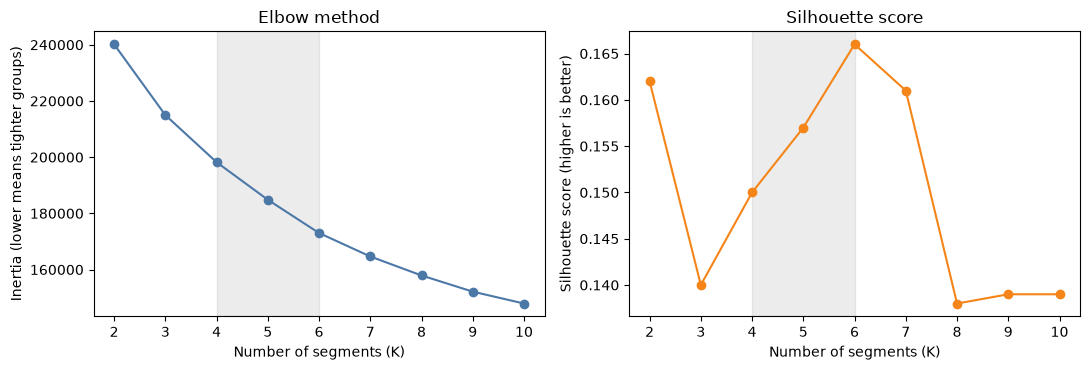

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(k_results["k"], k_results["inertia"], marker="o", color="#4C78A8")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of segments (K)")
axes[0].set_ylabel("Inertia (lower means tighter groups)")

axes[1].plot(k_results["k"], k_results["silhouette"], marker="o", color="#F58518")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of segments (K)")
axes[1].set_ylabel("Silhouette score (higher is better)")

for ax in axes:
    ax.axvspan(4, 6, color="grey", alpha=0.15)
    ax.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

## Step 2.3 Compare the allowed options: K = 4, 5, and 6

Within the allowed range, we add the stability check. For each K, we run K-means five times from different starting points and compare the results with the adjusted Rand index (ARI). An ARI of 1 means two runs gave identical groups. A value near 0 means the groups agree no more than chance.

In [16]:
def stability(k, seeds=(1, 2, 3, 4, 5)):
    label_sets = [
        KMeans(n_clusters=k, n_init=10, random_state=s).fit_predict(X_scaled)
        for s in seeds
    ]
    scores = [adjusted_rand_score(a, b) for a, b in combinations(label_sets, 2)]
    return np.mean(scores), np.min(scores)

comparison = k_results[k_results["k"].isin([4, 5, 6])][
    ["k", "silhouette", "smallest_group_share"]
].copy()
comparison = comparison.rename(columns={"smallest_group_share": "smallest_group_percent"})

stab = {k: stability(k) for k in [4, 5, 6]}
comparison["stability_average_ari"] = comparison["k"].map(lambda k: round(stab[k][0], 3))
comparison["stability_lowest_ari"] = comparison["k"].map(lambda k: round(stab[k][1], 3))
comparison["meets_5_percent_rule"] = comparison["smallest_group_percent"] >= 5
comparison.reset_index(drop=True)

,k,silhouette,smallest_group_percent,stability_average_ari,stability_lowest_ari,meets_5_percent_rule
0,4,0.150,13.0,1.000,0.999,True
1,5,0.157,8.1,0.999,0.998,True
2,6,0.166,4.9,0.999,0.999,False


## Step 2.4 Decide

**What the evidence shows**

- **The elbow curve has no sharp bend.** Inertia falls steadily. The gain from adding one more group shrinks gradually, from 10.5 percent at K=3 to 6.4 percent at K=6 and 2.8 percent at K=10.
- **Silhouette scores are low for every K, between 0.14 and 0.17.** Customer behavior changes gradually from one customer to the next, so the groups overlap and there are no clear gaps between them. This is common for customer behavior data. It means the segments are a practical way to divide customers, not natural separate groups, and some customers near the borders could fit two segments.
- **K=2 has a higher silhouette score than K=4 or K=5, but two groups are too coarse.** They could not support different campaigns, and the requirements ask for 4 to 6 segments.
- **Within 4 to 6, the silhouette scores differ by less than 0.02.** K=6 scores highest (0.166), but its smallest group holds 4.9 percent of customers, just under the 5 percent rule.
- **Stability is almost perfect for all three options.** Repeated runs give nearly identical groups, so this check confirms the results are reliable but does not help choose between 4, 5, and 6. It also covers requirement FR8 for the chosen K.

**Decision: K = 5**

- It meets every requirement: within the 4 to 6 range, smallest group at 8.1 percent, and stable.
- Its silhouette score (0.157) is within 0.01 of the best score in the range.
- Five segments give marketing more detail than four, and are easier to manage than six.

K=6 remains a close alternative. In Stage 4, we check whether the five segments are clearly different and useful. If two of them look the same, or one is too mixed, we can revisit this choice.

In [17]:
CHOSEN_K = 5
print(f"Chosen number of segments: {CHOSEN_K}")

Chosen number of segments: 5


### Stage 2 summary

**What we did**

- Tested K from 2 to 10 using the elbow method and the silhouette score.
- Compared K = 4, 5, and 6 on silhouette score, smallest group size, and stability.
- Chose K = 5 and explained why, including the fact that the scores are low and the options are close.

**What comes next**

Stage 3 builds the five segments, places every customer in one of them, and tests stability again using random subsamples of customers (requirement FR7).

---
# Stage 3: Build the segments

We now run K-means with the five groups we chose, and place every customer in one of them (requirement FR7). Then we test whether the segments hold up when the data changes a little.

## Step 3.1 Run the final model and assign customers

K-means picks starting points at random, and then moves the centre of each group until the groups settle. We run it 10 times from different starting points and keep the best result. The fixed seed means the answer is the same every time.

The segment numbers K-means gives are arbitrary. To make them easy to follow, we renumber the segments from largest (Segment 1) to smallest (Segment 5). Names that describe each segment come in Stage 4, after we have seen what the groups look like.

In [18]:
final_model = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_SEED)
raw_labels = final_model.fit_predict(X_scaled)

order = list(pd.Series(raw_labels).value_counts().index)
relabel = {old: new for new, old in enumerate(order, start=1)}

df["segment"] = pd.Series(raw_labels, index=df.index).map(relabel)
segment_labels = df["segment"].to_numpy()

centers_scaled = pd.DataFrame(
    final_model.cluster_centers_[order],
    columns=FINAL_FEATURES,
    index=range(1, CHOSEN_K + 1),
)

sizes = df["segment"].value_counts().sort_index()
size_table = pd.DataFrame({
    "customers": sizes,
    "percent_of_customers": (sizes / len(df) * 100).round(1),
})
size_table.index.name = "segment"
size_table

,customers,percent_of_customers
segment,,
1,5137,34.2
2,4051,27.0
3,2749,18.3
4,1848,12.3
5,1215,8.1


Every customer is in exactly one segment, and the smallest segment holds 8.1 percent of customers.


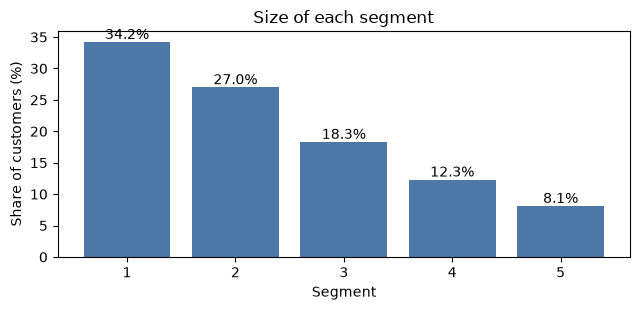

In [19]:
assert df["segment"].notna().all(), "Some customers have no segment"
assert size_table["customers"].sum() == len(df)
assert size_table["percent_of_customers"].min() >= 5, "A segment is smaller than 5 percent"
print("Every customer is in exactly one segment, and the smallest segment "
      f"holds {size_table['percent_of_customers'].min()} percent of customers.")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar(size_table.index.astype(str), size_table["percent_of_customers"], color="#4C78A8")
ax.set_xlabel("Segment")
ax.set_ylabel("Share of customers (%)")
ax.set_title("Size of each segment")
for x, v in zip(size_table.index.astype(str), size_table["percent_of_customers"]):
    ax.text(x, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

## Step 3.2 Test stability on random subsamples

In Stage 2 we re-ran K-means on all the customers from different starting points. Here we make the test harder. We take 20 random samples, each with 80 percent of the customers, and build a new set of segments from each sample. Then we place all customers into those new segments and compare the result with our final segments.

We use two measures:

- **Adjusted Rand index (ARI).** 1 means the two sets of segments are identical. Values near 0 mean they agree no more than chance.
- **Share of customers in the same segment.** After matching each new segment to its closest original segment, this is the percentage of customers who end up in the same segment as before.

In [20]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.cluster import contingency_matrix

def share_in_same_segment(labels_a, labels_b):
    table = contingency_matrix(labels_a, labels_b)
    rows, cols = linear_sum_assignment(-table)
    return table[rows, cols].sum() / table.sum()

rng = np.random.default_rng(RANDOM_SEED)
n_customers = len(X_scaled)
rows = []

for run in range(1, 21):
    sample_idx = rng.choice(n_customers, size=int(n_customers * 0.8), replace=False)
    sub_model = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=run)
    sub_model.fit(X_scaled.iloc[sample_idx])
    sub_labels = sub_model.predict(X_scaled)
    rows.append({
        "run": run,
        "ARI": adjusted_rand_score(segment_labels, sub_labels),
        "share_in_same_segment": share_in_same_segment(segment_labels, sub_labels),
    })

stability_table = pd.DataFrame(rows)
stability_table[["ARI", "share_in_same_segment"]].agg(["mean", "min", "max"]).round(3)

,ARI,share_in_same_segment
mean,0.993,0.997
min,0.985,0.993
max,0.995,0.998


**What the results mean**

- **The segments are very stable.** Across the 20 subsample tests, the average ARI is 0.993 and the lowest is 0.985. On average 99.7 percent of customers land in the same segment as before, and in the worst test 99.3 percent do.
- **Stable does not mean separate.** Stage 2 showed that the groups overlap, and that is still true. What the test shows is that the borders between segments fall in nearly the same place each time. The segments are a reliable way to divide customers, even though the groups blend into each other.
- **The sizes are workable.** The largest segment holds 34.2 percent of customers and the smallest holds 8.1 percent, so every segment is big enough to target with its own campaign.

## Step 3.3 Save the segments

We save the clean table with the segment number added, so that Stage 4 and the later documents can use it.

In [21]:
SEGMENTED_PATH = "../data/telcox_segmented.csv"
df.to_csv(SEGMENTED_PATH, index=False)
print(f"Saved {len(df):,} customers with their segment to {SEGMENTED_PATH}")

Saved 15,000 customers with their segment to ../data/telcox_segmented.csv


### Stage 3 summary

**What we did**

- Built five segments with K-means and placed every customer in exactly one of them.
- Numbered the segments from largest (34.2 percent) to smallest (8.1 percent).
- Tested stability on 20 random subsamples. At least 99.3 percent of customers kept the same segment in every test.

**What comes next**

Stage 4 describes who is in each segment, gives each segment a plain name, ranks the segments by upgrade potential, and checks whether five segments are clear and useful (requirements FR9 to FR11).

---
# Stage 4: Profile the segments

The segments so far are only numbers. In this stage we find out who is in each one, give each a plain name, and rank the segments by how ready they are to upgrade (requirements FR9 to FR11).

Segment profiles use the **real values** from the clean table, not the capped or scaled values used to build the segments.

## Step 4.1 Describe each segment

This table puts the five segments side by side. It covers size, usage, spending, account type, plan mix, and who the customers are. Age, area, and sign-up channel were not used to build the segments, so they help us check whether the groups make sense for real people.

In [22]:
g = df.groupby("segment")

def share(column, values):
    return g[column].apply(lambda s: s.isin(values).mean() * 100)

profile = pd.DataFrame({
    "Share of all customers (%)": g.size() / len(df) * 100,
    "Mobile data per month (GB)": g["avg_data_gb"].mean(),
    "Call minutes per month": g["avg_voice_min"].mean(),
    "Texts per month": g["avg_sms"].mean(),
    "Average monthly spend": g["avg_monthly_spend"].mean(),
    "Bundles bought in 3 months": g["bundle_purchases_3m"].mean(),
    "Months as a customer": g["tenure_months"].mean(),
    "Prepaid (%)": g["is_prepaid"].mean() * 100,
    "Has home broadband (%)": g["has_broadband"].mean() * 100,
    "On Basic plan (%)": share("current_plan", ["Basic"]),
    "On Standard plan (%)": share("current_plan", ["Standard"]),
    "On Plus or Premium plan (%)": share("current_plan", ["Plus", "Premium"]),
    "Aged 18 to 34 (%)": share("age_group", ["18-24", "25-34"]),
    "Aged 55 and over (%)": share("age_group", ["55+"]),
    "Lives in an urban area (%)": share("area_type", ["Urban"]),
    "Signed up through the app (%)": share("registration_channel", ["Mobile app"]),
}).T.round(1)
profile.columns = [f"Segment {c}" for c in profile.columns]
profile

,Segment 1,Segment 2,Segment 3,Segment 4,Segment 5
Share of all customers (%),34.2,27.0,18.3,12.3,8.1
Mobile data per month (GB),11.1,4.6,12.3,28.8,5.5
Call minutes per month,275.1,161.9,161.2,186.2,757.3
Texts per month,68.6,50.7,137.3,111.9,63.5
Average monthly spend,32.4,19.9,31.9,25.0,17.7
Bundles bought in 3 months,1.3,0.7,5.0,3.1,0.8
Months as a customer,41.7,34.0,21.8,24.7,56.7
Prepaid (%),0.0,100.0,99.7,39.6,27.2
Has home broadband (%),38.4,12.3,10.3,19.4,14.4
On Basic plan (%),18.4,52.8,37.3,65.2,58.8


## Step 4.2 See what makes each segment different

The table above has many numbers. This chart shows the same story at a glance. Each cell shows how far a segment's average sits from the average of all customers, measured in standard steps (the scaled values from Stage 1). Red means higher than average, blue means lower, and 0 means average.

If the five columns look clearly different from each other, the segments are doing their job.

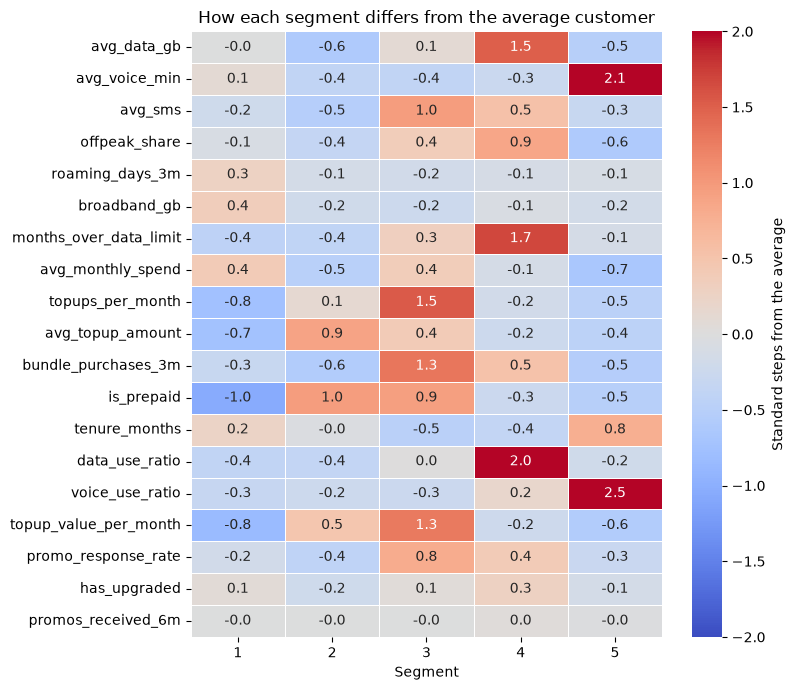

In [23]:
import seaborn as sns

plt.figure(figsize=(8, 7))
sns.heatmap(
    centers_scaled.T, cmap="coolwarm", center=0, vmin=-2, vmax=2,
    annot=True, fmt=".1f", linewidths=0.5, cbar_kws={"label": "Standard steps from the average"},
)
plt.xlabel("Segment")
plt.ylabel("")
plt.title("How each segment differs from the average customer")
plt.tight_layout()
plt.show()

## Step 4.3 Name each segment

Names should be short and based on what the data shows (requirement FR10). The table below gives each segment a name and a short description. The numbers in the descriptions come from the profile table above.

| Segment | Name | Description |
|---|---|---|
| 1 | **Steady Postpaid Households** | Postpaid customers who have been with TelcoX for about three and a half years on average. They use moderate amounts of data and calls, spend the most per month (about 32), and are the most likely to have home broadband (38 percent). Most stay within their plan limits. |
| 2 | **Light Prepaid Users** | Prepaid customers with light use. They average under 5 GB of data and about 160 call minutes a month, top up fewer than twice a month, and spend little (about 20). More than half are on the Basic plan. |
| 3 | **Deal-Seeking Prepaid Users** | Prepaid customers who top up often (about 4.7 times a month) in small amounts and buy about 5 bundles every three months. They respond to promotions more than any other segment (27 percent), and about half are under 35. |
| 4 | **Heavy Data Users** | The heaviest data users, at about 29 GB a month. Nearly all of them (99 percent) use more data than their plan allows, and 97 percent are on a Basic or Standard plan. They are the most urban segment and the most likely to have upgraded before. |
| 5 | **Long-Term Voice Users** | Customers who make far more calls than anyone else, about 760 minutes a month, which is above the call allowance of their plan in nearly every case. They have been customers the longest (about 4.7 years), skew older, and rarely use data or respond to promotions. |

**Note:** the names and descriptions were written for the data created with seed 42. If the data is regenerated with a different seed, the segment numbers and numbers in the descriptions may change.

In [24]:
SEGMENT_NAMES = {
    1: "Steady Postpaid Households",
    2: "Light Prepaid Users",
    3: "Deal-Seeking Prepaid Users",
    4: "Heavy Data Users",
    5: "Long-Term Voice Users",
}
df["segment_name"] = df["segment"].map(SEGMENT_NAMES)
df[["segment", "segment_name"]].drop_duplicates().sort_values("segment").reset_index(drop=True)

,segment,segment_name
0,1,Steady Postpaid Households
1,2,Light Prepaid Users
2,3,Deal-Seeking Prepaid Users
3,4,Heavy Data Users
4,5,Long-Term Voice Users


## Step 4.4 Rank the segments by upgrade potential

TelcoX wants to know which groups are most ready to move to a higher plan (requirement FR11). We look at three signs for each segment:

| Sign | What it measures | Why it matters |
|---|---|---|
| **Need** | Share of customers who use more data or more call minutes than their plan allows, and who are not already on the top plan. | These customers are paying for a plan that does not fit them. |
| **Past behavior** | Share of customers who upgraded in the last 24 months. | Customers who have upgraded before are likely to do it again. |
| **Responsiveness** | Average share of promotions the customer accepted. | Customers who say yes to offers are easier to reach. |

**How the score works.** Each sign is rescaled so the lowest segment gets 0 and the highest gets 1. The three are then combined, with need counting for half the score and the other two signs for a quarter each. The final score runs from 0 to 100. Need has the largest weight because a customer who has outgrown a plan has a clear reason to upgrade.

The weights are a judgment call, so we also check whether the ranking changes under other weights.

In [25]:
df["over_data_allowance"] = df["data_use_ratio"] > 1
df["over_voice_allowance"] = df["voice_use_ratio"] > 1
df["can_upgrade"] = df["current_plan"] != "Premium"
df["upgrade_ready"] = (df["over_data_allowance"] | df["over_voice_allowance"]) & df["can_upgrade"]

g = df.groupby("segment")
signs = pd.DataFrame({
    "need": g["upgrade_ready"].mean(),
    "past_upgrades": g["has_upgraded"].mean(),
    "responsiveness": g["promo_response_rate"].mean(),
})

def to_0_1(series):
    return (series - series.min()) / (series.max() - series.min())

signs_scaled = signs.apply(to_0_1)
WEIGHTS = {"need": 0.50, "past_upgrades": 0.25, "responsiveness": 0.25}

ranking = signs.copy()
ranking["upgrade_score"] = sum(signs_scaled[k] * w for k, w in WEIGHTS.items()) * 100
ranking["rank"] = ranking["upgrade_score"].rank(ascending=False).astype(int)
ranking.insert(0, "segment_name", ranking.index.map(SEGMENT_NAMES))

display_ranking = ranking.sort_values("rank").copy()
for col in ["need", "past_upgrades", "responsiveness"]:
    display_ranking[col] = (display_ranking[col] * 100).round(1)
display_ranking["upgrade_score"] = display_ranking["upgrade_score"].round(1)
display_ranking.rename(columns={
    "need": "need (%)", "past_upgrades": "upgraded before (%)",
    "responsiveness": "promo response (%)",
})

,segment_name,need (%),upgraded before (%),promo response (%),upgrade_score,rank
segment,,,,,,
4,Heavy Data Users,98.6,28.4,20.0,91.3,1
5,Long-Term Voice Users,99.3,12.2,7.1,56.1,2
3,Deal-Seeking Prepaid Users,50.6,19.7,27.4,54.6,3
1,Steady Postpaid Households,27.6,20.5,9.2,19.3,4
2,Light Prepaid Users,33.7,9.4,4.9,4.2,5


In [26]:
alternatives = {
    "Chosen weights (50 / 25 / 25)": {"need": 0.50, "past_upgrades": 0.25, "responsiveness": 0.25},
    "Equal weights": {"need": 1 / 3, "past_upgrades": 1 / 3, "responsiveness": 1 / 3},
    "Need only": {"need": 1.0, "past_upgrades": 0.0, "responsiveness": 0.0},
}
rank_check = pd.DataFrame({
    label: sum(signs_scaled[k] * w for k, w in weights.items()).rank(ascending=False).astype(int)
    for label, weights in alternatives.items()
})
rank_check.insert(0, "segment_name", rank_check.index.map(SEGMENT_NAMES))
rank_check

,segment_name,Chosen weights (50 / 25 / 25),Equal weights,Need only
segment,,,,
1,Steady Postpaid Households,4,4,5
2,Light Prepaid Users,5,5,4
3,Deal-Seeking Prepaid Users,3,2,3
4,Heavy Data Users,1,1,2
5,Long-Term Voice Users,2,3,1


## Step 4.5 See where plans do not fit

This chart supports the product team's question (user story US8): which segments use more than their plan allows? It shows the share of customers in each segment who go over their data allowance, their call allowance, or either.

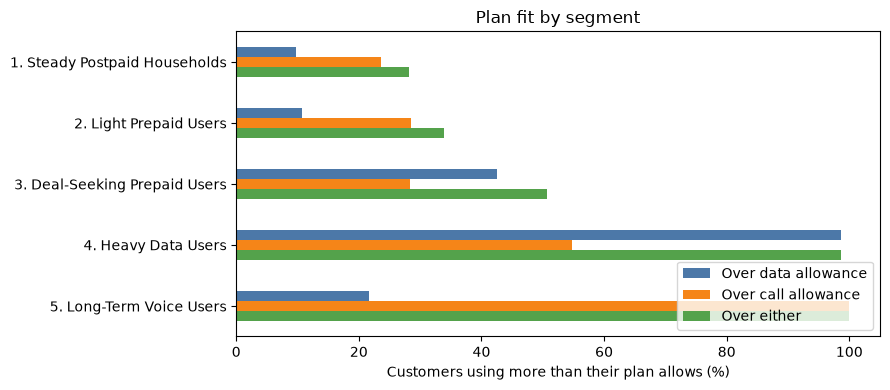

In [27]:
fit = g[["over_data_allowance", "over_voice_allowance"]].mean() * 100
fit["over_either"] = g.apply(lambda x: (x["over_data_allowance"] | x["over_voice_allowance"]).mean() * 100)
fit.index = [f"{i}. {SEGMENT_NAMES[i]}" for i in fit.index]

ax = fit.plot(kind="barh", figsize=(9, 4), color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_xlabel("Customers using more than their plan allows (%)")
ax.set_ylabel("")
ax.invert_yaxis()
ax.legend(["Over data allowance", "Over call allowance", "Over either"], loc="lower right")
plt.title("Plan fit by segment")
plt.tight_layout()
plt.show()

**What the ranking shows**

- **Heavy Data Users rank first** under the chosen weights and under equal weights. Under "need only" they come second, just behind Long-Term Voice Users (98.6 percent against 99.3 percent).
- **Long-Term Voice Users and Deal-Seeking Prepaid Users swap places 2 and 3** depending on the weights. They are two different kinds of opportunity. The voice users have the strongest need but rarely respond to promotions or upgrade. The deal-seekers have a more moderate need but respond to offers more than any other group.
- **Steady Postpaid Households and Light Prepaid Users are the bottom two in every version.** Their order with each other changes, but neither is a priority for upgrade campaigns.

## Step 4.6 Check whether six segments would be better

In Stage 2 we kept K=6 as a close alternative. Now that we can describe the five segments, we test it properly. We build a six-segment version and see how it relates to the five-segment version. If six segments only split one group into two similar halves, the extra segment adds little.

In [28]:
model6 = KMeans(n_clusters=6, n_init=10, random_state=RANDOM_SEED)
labels6_raw = model6.fit_predict(X_scaled)

order6 = list(pd.Series(labels6_raw).value_counts().index)
labels6 = pd.Series(labels6_raw).map({old: new for new, old in enumerate(order6, start=1)}).to_numpy()

overlap = pd.crosstab(labels6, df["segment"])
rows = []
for group, row in overlap.iterrows():
    main = row.idxmax()
    rows.append({
        "six_segment_group": group,
        "share_of_customers_%": round(row.sum() / len(df) * 100, 1),
        "mostly_from_segment": f"{main}. {SEGMENT_NAMES[main]}",
        "share_of_group_from_it_%": round(row[main] / row.sum() * 100, 1),
    })
pd.DataFrame(rows)

,six_segment_group,share_of_customers_%,mostly_from_segment,share_of_group_from_it_%
0,1,30.4,1. Steady Postpaid Households,98.7
1,2,26.5,2. Light Prepaid Users,99.9
2,3,18.3,3. Deal-Seeking Prepaid Users,99.7
3,4,12.0,4. Heavy Data Users,99.6
4,5,7.9,5. Long-Term Voice Users,99.5
5,6,4.9,1. Steady Postpaid Households,84.8


In [29]:
stay = (overlap.max(axis=0) / overlap.sum(axis=0) * 100).round(1)
pd.DataFrame({
    "segment": [f"{i}. {SEGMENT_NAMES[i]}" for i in stay.index],
    "share_that_stays_together_%": stay.values,
})

,segment,share_that_stays_together_%
0,1. Steady Postpaid Households,87.7
1,2. Light Prepaid Users,98.1
2,3. Deal-Seeking Prepaid Users,99.5
3,4. Heavy Data Users,96.8
4,5. Long-Term Voice Users,96.8


In [30]:
split_off = (labels6 == 6) & (df["segment"].to_numpy() == 1)
rest = (labels6 != 6) & (df["segment"].to_numpy() == 1)

measures = {
    "avg_data_gb": "Mobile data per month (GB)",
    "avg_voice_min": "Call minutes per month",
    "avg_monthly_spend": "Average monthly spend",
    "roaming_days_3m": "Roaming days in 3 months",
    "broadband_gb": "Home broadband data (GB)",
    "tenure_months": "Months as a customer",
    "data_use_ratio": "Share of data allowance used",
}
compare = pd.DataFrame({
    "Rest of Segment 1": df.loc[rest, list(measures)].mean(),
    "Group that splits off": df.loc[split_off, list(measures)].mean(),
}).rename(index=measures).round(1)
compare.loc["Customers"] = [int(rest.sum()), int(split_off.sum())]
compare

,Rest of Segment 1,Group that splits off
Mobile data per month (GB),9.9,19.7
Call minutes per month,254.7,422.5
Average monthly spend,30.7,44.8
Roaming days in 3 months,0.1,8.5
Home broadband data (GB),46.4,48.2
Months as a customer,40.8,48.4
Share of data allowance used,0.5,0.5
Customers,4512.0,625.0


**What the six-segment test shows**

- **Five of the six groups are almost unchanged.** Each one is at least 98.7 percent made up of one of the original segments.
- **The sixth group is a small piece carved out of Steady Postpaid Households.** It holds 4.9 percent of customers, which is just under the 5 percent rule, and about 12 percent of Segment 1 moves into it.
- **That piece is a real and distinct group.** Compared with the rest of Segment 1, these customers spend about 45 instead of 31, use twice as much data, make more calls, and roam abroad on about 8.5 days in three months, against almost none for the rest.

**Decision: keep five segments.** Six segments would add one small group and break the 5 percent rule, while leaving the other five unchanged. The roaming customers are still worth noting. In the marketing recommendations, they can be treated as a targeted add-on, such as a roaming offer for Steady Postpaid Households, without making them a separate segment.

## Step 4.7 Save the results

We save the segment profiles, the upgrade ranking, and the customer table with segment names, so the later documents can use them.

In [31]:
PROFILE_PATH = "../data/segment_profiles.csv"
RANKING_PATH = "../data/upgrade_ranking.csv"

profile.to_csv(PROFILE_PATH)
display_ranking.to_csv(RANKING_PATH)
df.to_csv(SEGMENTED_PATH, index=False)
print("Saved segment profiles, upgrade ranking, and the customer table with segment names.")

Saved segment profiles, upgrade ranking, and the customer table with segment names.


### Stage 4 summary

**What we did**

- Profiled the five segments side by side and showed what makes each one different.
- Gave each segment a plain name and a short description.
- Ranked the segments by upgrade potential. **Heavy Data Users** come first. **Long-Term Voice Users** and **Deal-Seeking Prepaid Users** follow, and their order depends on the weights. **Steady Postpaid Households** and **Light Prepaid Users** are the lowest.
- Showed which segments use more than their plan allows.
- Tested six segments and kept five, noting a small roaming group inside Steady Postpaid Households.

**What comes next**

The analysis is complete. The next documents turn these results into the data quality report, the segment profiles, the marketing recommendations, the KPI plan, and the executive summary.